In [13]:
import pandas as pd
df = pd.read_csv('c:/data/mushroom/mushrooms.csv')
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [14]:
X = df.iloc[:, 1:]
y = df['class']
df['class'].value_counts()
# 0 식용, 1 독버섯

class
e    4208
p    3916
Name: count, dtype: int64

In [15]:
#언더샘플링
from imblearn.under_sampling import RandomUnderSampler
X_sample, y_sample = RandomUnderSampler(random_state=0).fit_resample(X,y)
X_samp = pd.DataFrame(data=X_sample, columns=X.columns)

In [29]:
df_samp['class'].value_counts()

class
e    3916
p    3916
Name: count, dtype: int64

In [16]:
#라벨인코더 - 카테고리형 데이터를 숫자형으로 변화하는 함수
#주의 ; 가중치가 부여될 수 있음
from sklearn.preprocessing import LabelEncoder
lbl = LabelEncoder()
for col in df.columns:
    df[col] = lbl.fit_transform(df[col])
    print(lbl.classes_)

['e' 'p']
['b' 'c' 'f' 'k' 's' 'x']
['f' 'g' 's' 'y']
['b' 'c' 'e' 'g' 'n' 'p' 'r' 'u' 'w' 'y']
['f' 't']
['a' 'c' 'f' 'l' 'm' 'n' 'p' 's' 'y']
['a' 'f']
['c' 'w']
['b' 'n']
['b' 'e' 'g' 'h' 'k' 'n' 'o' 'p' 'r' 'u' 'w' 'y']
['e' 't']
['?' 'b' 'c' 'e' 'r']
['f' 'k' 's' 'y']
['f' 'k' 's' 'y']
['b' 'c' 'e' 'g' 'n' 'o' 'p' 'w' 'y']
['b' 'c' 'e' 'g' 'n' 'o' 'p' 'w' 'y']
['p']
['n' 'o' 'w' 'y']
['n' 'o' 't']
['e' 'f' 'l' 'n' 'p']
['b' 'h' 'k' 'n' 'o' 'r' 'u' 'w' 'y']
['a' 'c' 'n' 's' 'v' 'y']
['d' 'g' 'l' 'm' 'p' 'u' 'w']


In [26]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1


In [17]:
#원핫인코딩(get_dummies)
X_samp = pd.get_dummies(X_samp, columns=X_samp.columns, drop_first=True)
y_samp = pd.DataFrame(data=y_sample, columns=['class'])
df_samp = pd.concat([X_samp, y_samp], axis=1)
df_samp.head()

,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_g,cap-surface_s,cap-surface_y,cap-color_c,cap-color_e,...,population_s,population_v,population_y,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w,class
4923,False,True,False,False,False,False,False,True,False,True,...,False,False,True,False,False,False,False,False,False,e
2391,False,False,False,False,True,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,e
2970,False,True,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,e
219,False,False,False,True,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,e
3503,False,True,False,False,False,False,False,True,False,True,...,False,False,True,False,False,False,False,False,False,e


In [19]:
X = df_samp.iloc[:, :-1]
y = df_samp['class']

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=0)

In [21]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [22]:
from sklearn.metrics import accuracy_score, classification_report
pred = model.predict(X_test)
score = accuracy_score(y_test, pred)
report = classification_report(y_test, pred)
print('정답률:', score)
print('리포트:\n', report)
#100% 분류성공

정답률: 1.0
리포트:
               precision    recall  f1-score   support

           e       1.00      1.00      1.00       979
           p       1.00      1.00      1.00       979

    accuracy                           1.00      1958
   macro avg       1.00      1.00      1.00      1958
weighted avg       1.00      1.00      1.00      1958



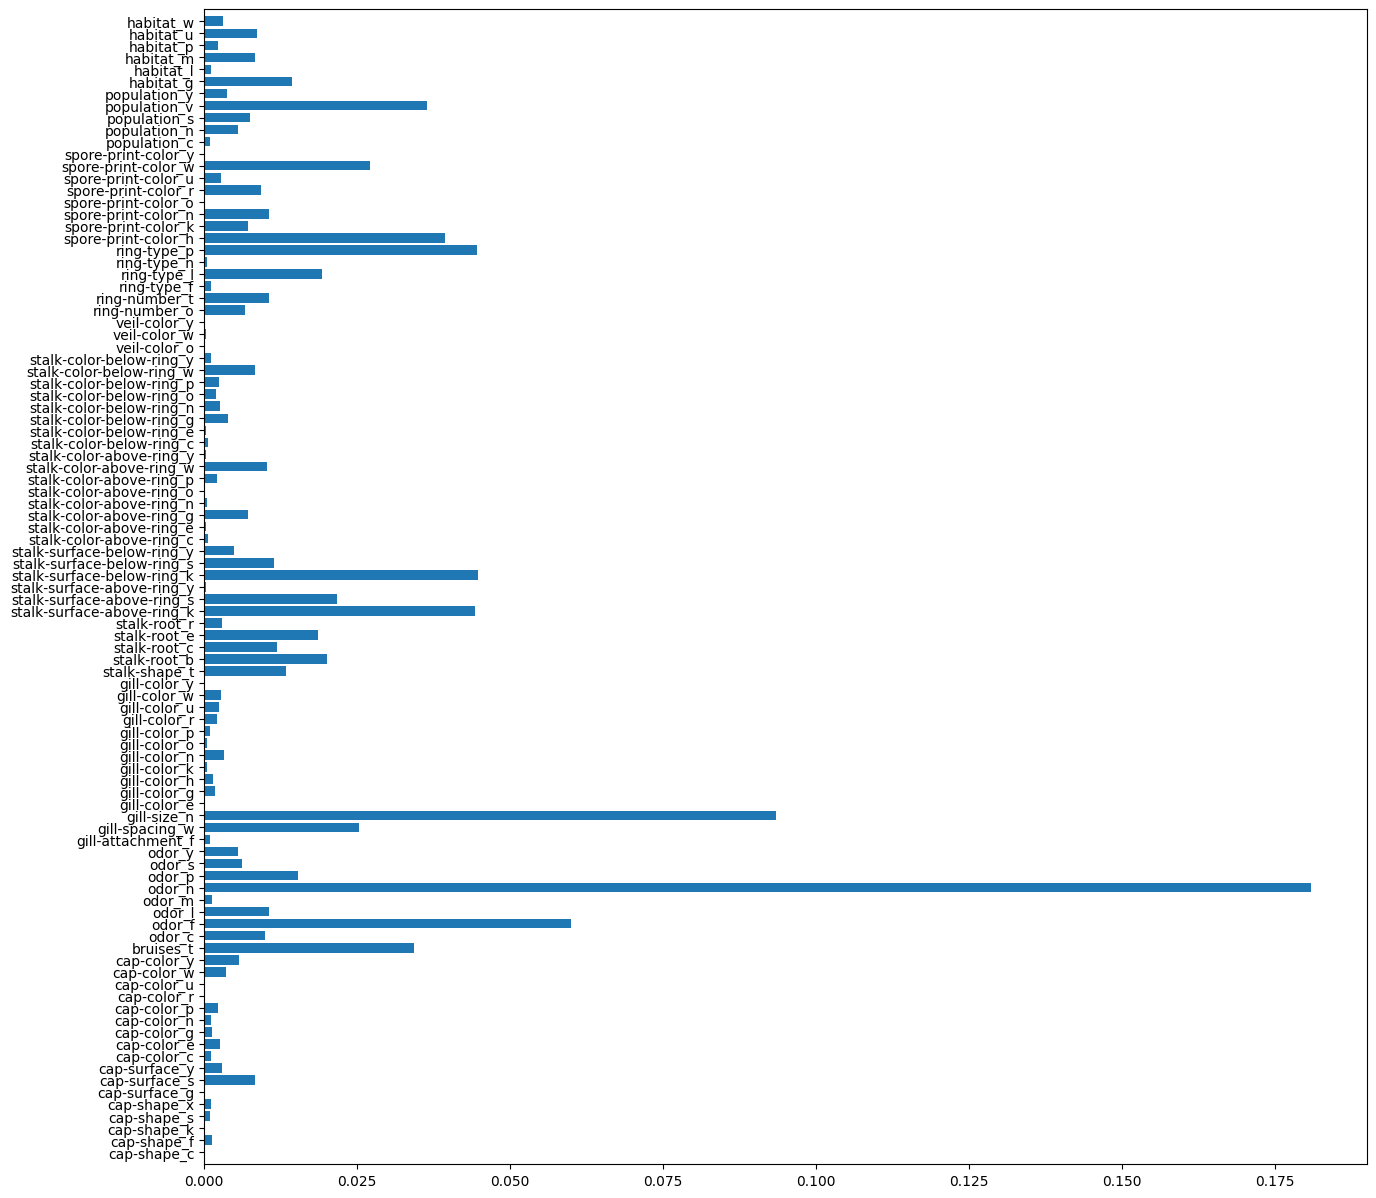

In [28]:
import numpy as np
import matplotlib.pyplot as plt
def plot_tree(model):
    n_features = X.shape[1]
    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), X.columns)
    plt.ylim(-1, n_features)

plt.figure(figsize=(15,15))
plot_tree(model)


In [24]:
#기여도가 가장 높은 변수의 인덱스위치(argmax)
np.argmax(model.feature_importances_)

np.int64(22)

In [25]:
X.columns[22]

'odor_n'